# The SIDM background estimate from first principles — Part 5: the frozen background prescription and first expected limits

Part 4 delivered validated but *statistical-only* background estimates under
the three blind windows. This notebook freezes the full background
prescription — fit choice, bias corrections, and every uncertainty — and uses
it to compute the analysis's first **median expected 95% CLs upper limits on
σ×BR**, per signal grid point, in both channels.

**No unblinding is involved anywhere in this notebook**: expected limits use
only the background estimates (from sidebands) and the signal simulation. The
blind windows stay blind; observed limits come much later, after the
collaboration-level unblinding steps.

## The frozen prescription

| Ingredient | Choice | Basis |
|---|---|---|
| Primary fit family | power law × exponential (`expow`, 3 par) | best-validated family, Parts 3–4 |
| 4mu (all windows), 2mu2e W100 | **local masked fit** as in Part 4 | validated in open regions and in the pass regions |
| 2mu2e W500, W1000 | **coarse wide-range fit**: expow fitted to a 50-GeV rebin of [150, 1000) with the windows masked, then integrated over the exact window on the 10-GeV grid | the 10-GeV sidebands are too sparse; construction validated on the open B and D2 regions below |
| Bias correction, 4mu local fits | × 0.876, bias systematic 5.3% | that channel's own in-pass fractional over-prediction (Part 4) |
| Bias correction, 2mu2e local fits | × 1.00, bias systematic 12% | Part 4 measured no significant 2mu2e bias; the systematic covers its measurement precision |
| Bias correction, coarse fit | × 1.00, bias systematic 15% | its own open-region validation (Section 1) shows a mild over-prediction, same sign as the local fits, consistent with zero at the validation's precision |
| Statistical uncertainty | parametric bootstrap (Poisson-fluctuate the sideband around the fit, refit, ×200) | propagates fit-parameter uncertainty |
| Family systematic | \|exp-family integral − expow integral\| | two-family envelope |
| Signal efficiency | window content / **physical generated events**, i.e. the stored-event count corrected by the per-point generator-filter efficiency (Section 3) | σ×BR refers to the full physical process |
| Limit construction | single-bin counting, asymptotic median expected 95% CLs (Asimov n = b), background profiled with a Gaussian constraint of the total width | standard asymptotic construction |
| Look-elsewhere | not applicable to expected limits | deferred to any future observed-significance quote |

Known limitations, stated up front: (i) for small backgrounds the asymptotic
construction is optimistic and the symmetric Gaussian background constraint is
a poor model of an asymmetric small-count uncertainty — the 2mu2e **W1000
entry (b ≈ 0.3 ± 0.5) is an order-of-magnitude placeholder pending toy-based
limits**, and the W500 entries carry the same caveat in milder form; (ii) the
W100 background sits on the low-mass turnover regime that the local fit does
not model well (Part 4), so its bias systematic may be underestimated;
(iii) the coarse fitter, like the local one, is validated in iso-*fail* open
regions — its transfer to the iso-pass A region is an assumption (the Part-4
caveat applies to it equally); (iv) signal-efficiency systematics (trigger,
reconstruction, the prompt-to-displaced vertexing transfer of Part 2) are not
yet included.

In [1]:
import glob, io, json, math, contextlib
import numpy as np
import coffea.util as cu
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.optimize import minimize, minimize_scalar
from scipy import stats as st
plt.style.use(hep.style.CMS)

WINC = "/uscms_data/d3/murtazas/abcd_mjjwin_local"    # windowed data pass (backgrounds)
FINE = "/uscms_data/d3/murtazas/abcd_mjjfine_local"   # fine campaign (signal MC)
GENJ = "/uscms_data/d3/murtazas/abcd_scan/signal_gencounts.json"  # per-point Runs.genEventCount harvest
LUMI_FB = 59.8
CBIAS_LOCAL = {"4mu": 0.876, "2mu2e": 1.00}
SYST_BIAS_LOCAL = {"4mu": 0.053, "2mu2e": 0.12}
CBIAS_COARSE, SYST_BIAS_COARSE = 1.00, 0.15
NBOOT = 200
rng = np.random.default_rng(20260719)

H = {}
for f in sorted(glob.glob(WINC + "/DoubleMuon_*.coffea")):
    o = cu.load(f); o = o.get("out", o)
    for ds in o.values():
        for k in ("abcd_mjjfine_4mu", "abcd_mjjfine_2mu2e"):
            h = ds["hists"][k]
            H[k] = h.copy() if k not in H else H[k] + h
h4 = H["abcd_mjjfine_4mu"][{"channel": "4mu_abcd_scan_data_win"}]
MJ = np.asarray(h4.axes["mjjf"].edges); CTR = 0.5 * (MJ[:-1] + MJ[1:]); CTR[-1] = 1000.
JTOP = len(CTR) - 1
def ei(v): return int(np.argmin(np.abs(MJ - v)))
SP = h4.view()["value"].sum(axis=-1)[1, 0:2, 0:2, :].sum(axis=(0, 1))
v2 = H["abcd_mjjfine_2mu2e"][{"channel": "2mu2e_abcd_scan_data_win"}].view()["value"].sum(axis=-1)
A2 = v2[:, 0:2, 0:2, 0:2, 1, 1, :].sum(axis=(0, 1, 2, 3))
B2 = v2[:, 0:2, 2, 0:2, 1, 1, :].sum(axis=(0, 1, 2))
D2 = v2[:, 0:2, 2, 2:, 1, 1, :].sum(axis=(0, 1, 2))
BLIND = ((CTR >= 80) & (CTR < 130)) | ((CTR >= 380) & (CTR < 600)) | (CTR >= 780)
assert SP[BLIND].sum() == 0 and A2[BLIND].sum() == 0, "window-blinding violation"
print("spectra loaded; window bins empty (blinding verified)")

def f_expow(m, p): return np.exp(p[0] - abs(p[1]) * m / 100.) * (m / 100.) ** (-p[2])
def f_exp(m, p):   return np.exp(p[0] - abs(p[1]) * m / 100.)

def nllfit(fam, npar, m, n, bw):
    def nll(p):
        mu = np.clip(fam(m, p) * bw, 1e-9, None)
        return float(np.sum(mu - n * np.log(mu)))
    p0 = [math.log(max(n.max(), 1) / bw + 1e-9), 0.5, 1.][:npar]
    return minimize(nll, p0, method="Nelder-Mead",
                    options={"maxiter": 20000, "fatol": 1e-9}).x

def fit_predict(counts, ilo, ihi, mask, jc1, jc2, fam=f_expow, npar=3, boot=True):
    m, n = CTR[ilo:ihi], counts[ilo:ihi]
    p = nllfit(fam, npar, m[mask], n[mask], 10.)
    pred = float(np.clip(fam(CTR[jc1:jc2], p) * 10., 0, None).sum())
    stat = None
    if boot:
        vals = []
        for _ in range(NBOOT):
            nt = rng.poisson(np.clip(fam(m[mask], p) * 10., 1e-9, None))
            pt = nllfit(fam, npar, m[mask], nt, 10.)
            vals.append(np.clip(fam(CTR[jc1:jc2], pt) * 10., 0, None).sum())
        stat = float(np.std(vals))
    return pred, stat

def coarse_fit_predict(counts, wlo, whi, boot=True, fam=f_expow, npar=3):
    '''50-GeV-rebinned masked fit of [150,1000); the fitted density is integrated
    over the EXACT window [wlo,whi) on the 10-GeV grid, so background and signal
    always share the same mass range.'''
    e50 = np.arange(150., 1001., 50.)
    c50 = np.array([counts[ei(a):ei(b)].sum() for a, b in zip(e50[:-1], e50[1:])])
    m50 = 0.5 * (e50[:-1] + e50[1:])
    open50 = np.array([not BLIND[ei(a):ei(b)].any() for a, b in zip(e50[:-1], e50[1:])])
    p = nllfit(fam, npar, m50[open50], c50[open50], 50.)
    jf1, jf2 = ei(wlo), ei(whi)
    pred = float(np.clip(fam(CTR[jf1:jf2], p) * 10., 0, None).sum())
    stat = None
    if boot:
        vals = []
        for _ in range(NBOOT):
            nt = rng.poisson(np.clip(fam(m50[open50], p) * 50., 1e-9, None))
            pt = nllfit(fam, npar, m50[open50], nt, 50.)
            vals.append(np.clip(fam(CTR[jf1:jf2], pt) * 10., 0, None).sum())
        stat = float(np.std(vals))
    return pred, stat

spectra loaded; window bins empty (blinding verified)


## 1. Validating the coarse wide-range fitter where everything is open

Before the coarse fitter may predict the 2mu2e W500/W1000 backgrounds, it must
demonstrate itself on the open B and D2 regions: fit them with the *same*
masking (the real window ranges held out) and compare the held-out prediction —
integrated over exactly the held-out range — with the observation over that
same range. The result is a mild over-prediction, the same sign as the local
fits and consistent with zero at the validation's precision; this is the basis
of the coarse fitter's bias treatment (no correction, 15% systematic) in the
prescription table. As with the local fits, validating in iso-fail regions and
applying in the iso-pass A region is a region-transfer assumption.

In [2]:
print("2mu2e coarse-fit validation on open regions (windows held out; exact-range comparison):")
for name, c in (("B", B2), ("D2", D2)):
    for wlo, whi in ((380., 600.), (780., 1000.)):
        pred, _ = coarse_fit_predict(c, wlo, whi, boot=False)
        obs = float(c[ei(wlo):ei(whi)].sum())
        z = (obs - pred) / math.sqrt(max(pred, 1.))
        print("  %-3s held-out [%4.0f,%4.0f): obs=%5.0f  pred=%6.1f  z=%+.1f"
              % (name, wlo, whi, obs, pred, z))

2mu2e coarse-fit validation on open regions (windows held out; exact-range comparison):
  B   held-out [ 380, 600): obs=    7  pred=   6.7  z=+0.1
  B   held-out [ 780,1000): obs=    0  pred=   0.0  z=-0.0
  D2  held-out [ 380, 600): obs=  127  pred= 135.1  z=-0.7
  D2  held-out [ 780,1000): obs=    4  pred=   3.9  z=+0.1


## 2. The frozen background estimates

In [3]:
SPECS = {
    ("4mu", "W100"): dict(kind="local", c=SP, ilo=ei(40.), ihi=ei(230.), w=(80., 130.)),
    ("4mu", "W500"): dict(kind="local", c=SP, ilo=ei(230.), ihi=ei(780.), w=(380., 600.)),
    ("4mu", "W1000"): dict(kind="local", c=SP, ilo=ei(600.), ihi=JTOP, w=(780., 1000.)),
    ("2mu2e", "W100"): dict(kind="local", c=A2, ilo=ei(40.), ihi=ei(230.), w=(80., 130.)),
    ("2mu2e", "W500"): dict(kind="coarse", c=A2, w=(380., 600.)),
    ("2mu2e", "W1000"): dict(kind="coarse", c=A2, w=(780., 1000.)),
}
BKG = {}
print("%-6s %-6s %9s | %9s %22s" % ("chan", "window", "raw fit", "b (corr)", "uncertainty breakdown"))
for (ch, wn), s in SPECS.items():
    wlo, whi = s["w"]
    if s["kind"] == "local":
        mask = ~BLIND[s["ilo"]:s["ihi"]]
        pred, stat = fit_predict(s["c"], s["ilo"], s["ihi"], mask, ei(wlo), ei(whi))
        alt, _ = fit_predict(s["c"], s["ilo"], s["ihi"], mask, ei(wlo), ei(whi), fam=f_exp, npar=2, boot=False)
        cb, sb = CBIAS_LOCAL[ch], SYST_BIAS_LOCAL[ch]
    else:
        pred, stat = coarse_fit_predict(s["c"], wlo, whi)
        alt, _ = coarse_fit_predict(s["c"], wlo, whi, boot=False, fam=f_exp, npar=2)
        cb, sb = CBIAS_COARSE, SYST_BIAS_COARSE
    b = cb * pred
    e = (cb * stat, cb * abs(alt - pred), sb * b)
    tot = math.sqrt(sum(x * x for x in e))
    BKG[(ch, wn)] = (b, tot)
    print("%-6s %-6s %9.1f | %6.1f +- %-5.1f (stat %.1f, family %.1f, bias %.1f)"
          % (ch, wn, pred, b, tot, *e))

chan   window   raw fit |  b (corr)  uncertainty breakdown


4mu    W100       268.2 |  234.9 +- 26.1  (stat 17.0, family 15.3, bias 12.5)


4mu    W500       704.4 |  617.1 +- 64.4  (stat 39.3, family 39.2, bias 32.7)


4mu    W1000      414.2 |  362.9 +- 106.5 (stat 104.5, family 7.4, bias 19.2)


2mu2e  W100        33.5 |   33.5 +- 13.6  (stat 9.5, family 8.9, bias 4.0)


2mu2e  W500         5.5 |    5.5 +- 3.0   (stat 2.7, family 1.0, bias 0.8)


2mu2e  W1000        0.3 |    0.3 +- 0.5   (stat 0.4, family 0.2, bias 0.0)


## 3. Signal efficiencies — including the generator filter

The signal productions carry a **generator-level filter**: the `Runs` tree's
`genEventCount` records all generated events, while the stored `Events` trees
contain only the filter survivors. Harvested over every file of all 26 grid
points, the filter efficiencies are 9.5–10.5%. For the reference point
`4Mu_500GeV_1p2GeV_1p9mm`: 2,600,709 generated vs 250,763 stored events
(filter efficiency 0.0964), against a campaign-processed count of 235,063
(the small difference is unprocessed files, ~6%).

Since σ×BR refers to the **full physical process**, the efficiency denominator
must be the *generated* count:
$\varepsilon = (\text{window content}/\text{processed events}) \times
(\text{stored}/\text{generated})$. Neglecting the filter would overstate every
efficiency — and tighten every limit — by a factor ~10.

Efficiencies range from ~0.07 (prompt 500 GeV in 4mu) down to ~0 (the prompt
100 GeV point in 2mu2e, whose prompt electrons fail the displaced-EGM
requirement of the A corner — a genuine no-sensitivity configuration, not an
error).

In [4]:
GEN = json.load(open(GENJ))
def nproc(ds, ch):
    cf = ds["cutflow"][ch]
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf): cf.print_table()
    for line in buf.getvalue().splitlines():
        if line.startswith("None"):
            return float(line.split()[1])
    raise RuntimeError("no initial cutflow row")

SIG = {}
print("%-32s %-6s %-6s %10s %12s" % ("point", "chan", "window", "filter eff", "eff (total)"))
for f in sorted(glob.glob(FINE + "/4Mu_*.coffea")) + sorted(glob.glob(FINE + "/2Mu2E_*.coffea")):
    name = f.split("/")[-1].replace(".coffea", "")
    ch = "4mu" if name.startswith("4Mu") else "2mu2e"
    chan = ch + "_abcd_scan"
    mass = float(name.split("_")[1].replace("GeV", ""))
    wn = {100.: "W100", 500.: "W500", 1000.: "W1000"}[mass]
    wlo, whi = {"W100": (80., 130.), "W500": (380., 600.), "W1000": (780., 1000.)}[wn]
    o = cu.load(f); o = o.get("out", o)
    ds = list(o.values())[0]
    v = ds["hists"]["abcd_mjjfine_" + ch][{"channel": chan}].view()["value"].sum(axis=-1)
    spec = (v[1, 0:2, 0:2, :].sum(axis=(0, 1)) if ch == "4mu"
            else v[:, 0:2, 0:2, 0:2, 1, 1, :].sum(axis=(0, 1, 2, 3)))
    feff = GEN[name]["events"] / GEN[name]["genEventCount"]
    eff = (spec[ei(wlo):ei(whi)].sum() / nproc(ds, chan)) * feff
    SIG[name] = (ch, wn, eff)
    print("%-32s %-6s %-6s %10.4f %12.6f" % (name, ch, wn, feff, eff))

point                            chan   window filter eff  eff (total)
4Mu_1000GeV_1p2GeV_0p0096mm      4mu    W1000      0.0965     0.027769
4Mu_1000GeV_1p2GeV_0p96mm        4mu    W1000      0.0967     0.009614
4Mu_1000GeV_1p2GeV_9p6mm         4mu    W1000      0.0997     0.000826
4Mu_100GeV_1p2GeV_0p096mm        4mu    W100       0.0960     0.040913
4Mu_100GeV_1p2GeV_96p0mm         4mu    W100       0.1006     0.003662
4Mu_100GeV_1p2GeV_9p6mm          4mu    W100       0.0999     0.021405
4Mu_500GeV_0p25GeV_0p4mm         4mu    W500       0.0961     0.025532
4Mu_500GeV_0p25GeV_4p0mm         4mu    W500       0.1052     0.003143
4Mu_500GeV_1p2GeV_0p019mm        4mu    W500       0.0971     0.068826
4Mu_500GeV_1p2GeV_19p0mm         4mu    W500       0.0956     0.003551
4Mu_500GeV_1p2GeV_1p9mm          4mu    W500       0.0964     0.031289
4Mu_500GeV_5p0GeV_80p0mm         4mu    W500       0.0960     0.004919
4Mu_500GeV_5p0GeV_8p0mm          4mu    W500       0.0958     0.033777
2Mu2E_

## 4. Median expected 95% CLs limits on σ×BR

Single-bin counting per point: signal strength s enters as
$s = \sigma{\times}BR \cdot L \cdot \varepsilon$; the background is profiled
with a Gaussian constraint of the total width from Section 2; the median
expected limit solves $\tilde q_s = 3.84$ on the background-only Asimov
dataset. Points sharing a window share the same background — their limits
differ only through $\varepsilon$. The 2mu2e W1000 entries are
**order-of-magnitude placeholders** (prescription table, limitation i).

**How to read the figure**: expected upper limit (95% CL) on σ×BR versus
dark-photon lifetime, one panel per bound-state mass, both channels, log–log;
within a panel, marker/line styles distinguish the dark-photon masses
(0.25 / 1.2 / 5 GeV), since the efficiency depends on it. The dashed grey
line marks 1 fb, the placeholder reference cross-section — no point reaches
it at these v1 uncertainties.

point                            window      b +- db        eff        UL [fb]
2Mu2E_100GeV_1p2GeV_0p096mm      W100     33.5+-13.6   0.000002       265309.8


2Mu2E_100GeV_1p2GeV_96p0mm       W100     33.5+-13.6   0.000389         1252.9
2Mu2E_100GeV_1p2GeV_9p6mm        W100     33.5+-13.6   0.001161          420.3
4Mu_100GeV_1p2GeV_0p096mm        W100    234.9+-26.1   0.040913           24.4
4Mu_100GeV_1p2GeV_96p0mm         W100    234.9+-26.1   0.003662          272.2
4Mu_100GeV_1p2GeV_9p6mm          W100    234.9+-26.1   0.021405           46.6
2Mu2E_1000GeV_1p2GeV_0p0096mm    W1000     0.3+- 0.5   0.000137          323.2  (placeholder)
2Mu2E_1000GeV_1p2GeV_0p96mm      W1000     0.3+- 0.5   0.005945            7.5  (placeholder)
2Mu2E_1000GeV_1p2GeV_9p6mm       W1000     0.3+- 0.5   0.001032           43.1  (placeholder)
4Mu_1000GeV_1p2GeV_0p0096mm      W1000   362.9+-106.5   0.027769          127.7
4Mu_1000GeV_1p2GeV_0p96mm        W1000   362.9+-106.5   0.009614          368.8
4Mu_1000GeV_1p2GeV_9p6mm         W1000   362.9+-106.5   0.000826         4291.4
2Mu2E_500GeV_0p25GeV_0p4mm       W500      5.5+- 3.0   0.020169            6.7
2Mu2

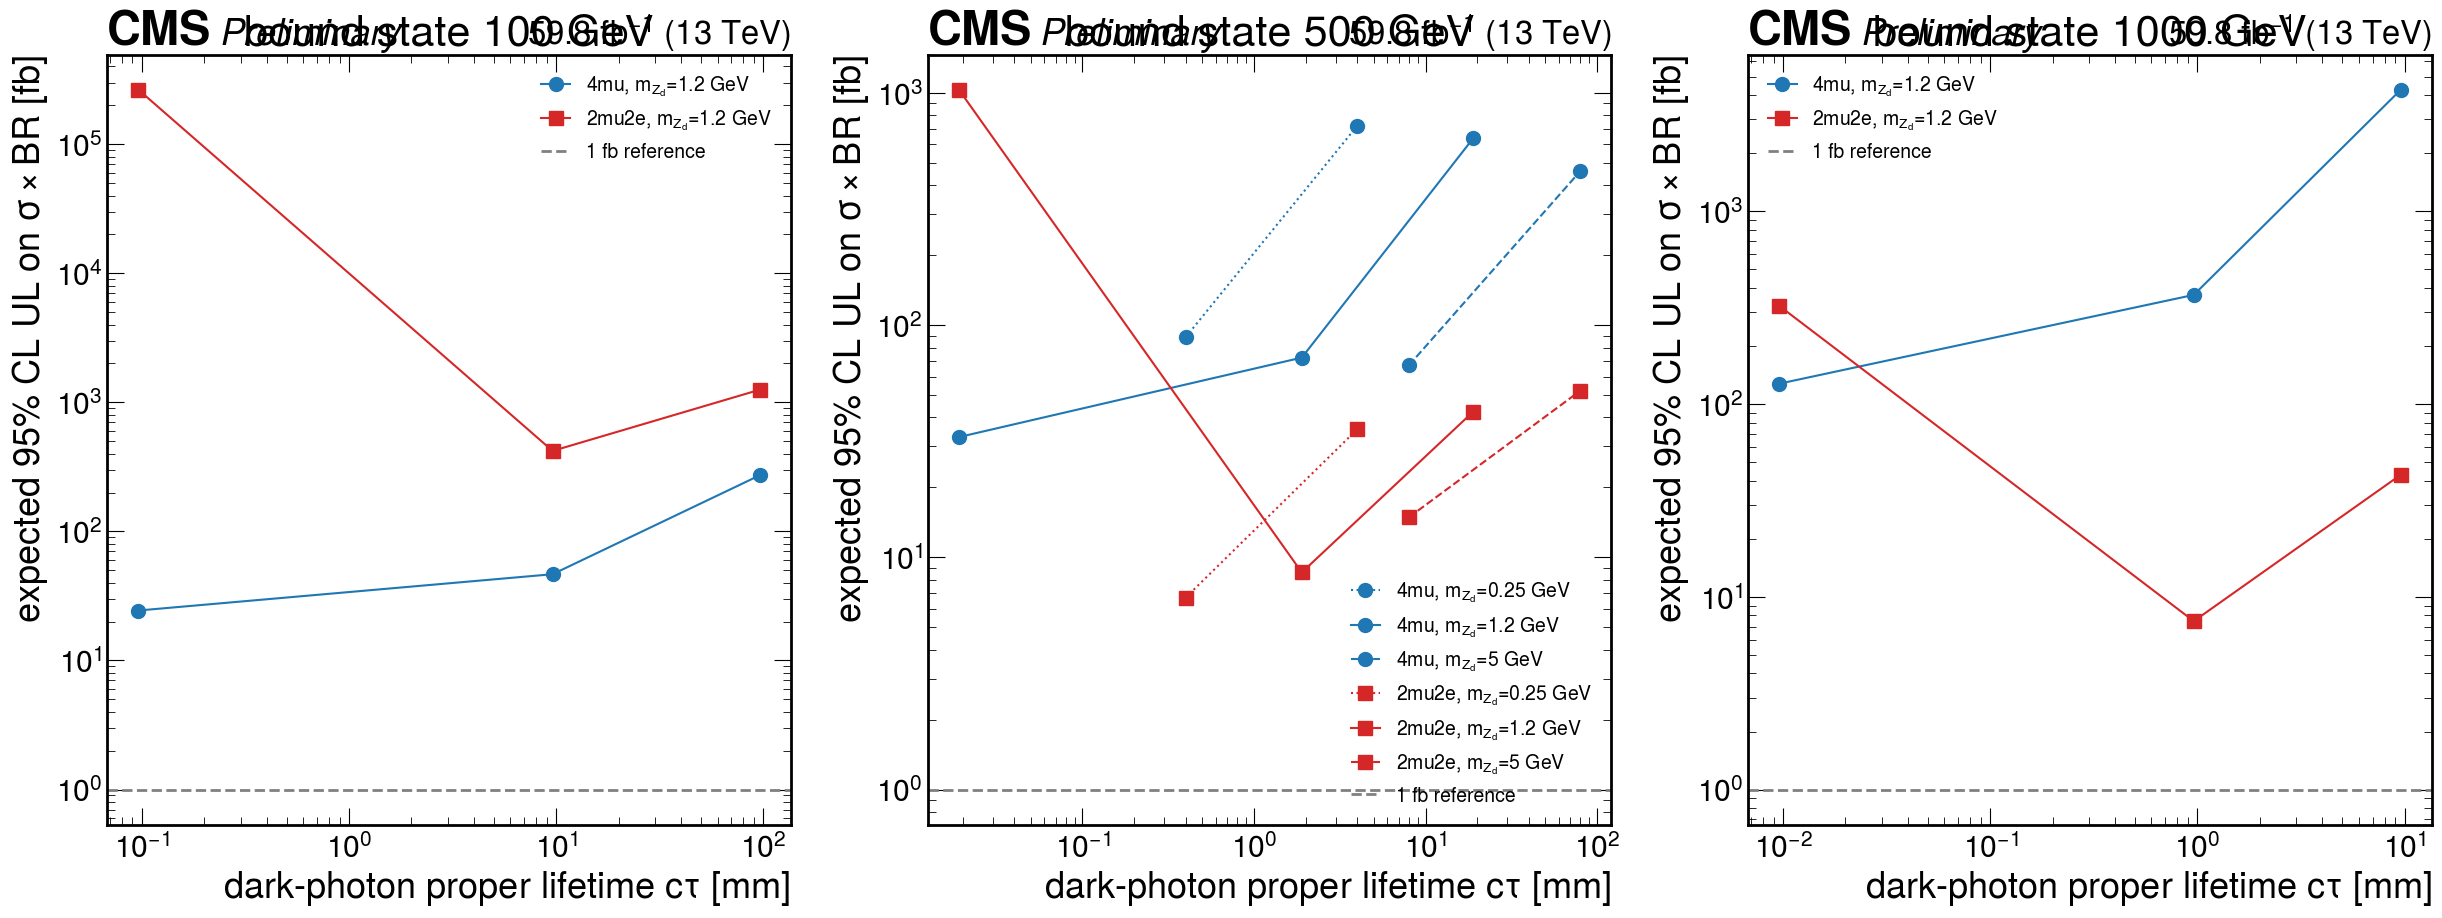

In [5]:
def expected_ul(b, sb):
    n = b
    def q_s(s):
        def nll(bp):
            mu = max(s + bp, 1e-9)
            return mu - n * math.log(mu) + 0.5 * ((bp - b) / max(sb, 1e-9)) ** 2
        r = minimize_scalar(nll, bounds=(max(1e-6, b - 8 * sb), b + 8 * sb), method="bounded")
        nll0 = (b - n * math.log(b)) if b > 0 else 0.0
        return 2.0 * max(r.fun - nll0, 0.0)
    lo, hi = 0.0, 10.0 + 3.0 * math.sqrt(b + sb * sb)
    while q_s(hi) < 3.84: hi *= 2
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if q_s(mid) < 3.84 else (lo, mid)
    return 0.5 * (lo + hi)

RES = {}
print("%-32s %-6s %12s %10s %14s" % ("point", "window", "b +- db", "eff", "UL [fb]"))
for name, (ch, wn, eff) in sorted(SIG.items(), key=lambda kv: (kv[1][1], kv[1][0], kv[0])):
    b, sb = BKG[(ch, wn)]
    sUL = expected_ul(b, sb)
    ul = sUL / (LUMI_FB * eff) if eff > 0 else float("inf")
    note = "  (placeholder)" if (ch, wn) == ("2mu2e", "W1000") else ""
    RES[name] = (ch, wn, eff, ul)
    print("%-32s %-6s %6.1f+-%4.1f %10.6f %14s%s"
          % (name, wn, b, sb, eff, ("%.1f" % ul) if np.isfinite(ul) else "no sensitivity", note))

def parse(name):
    parts = name.split("_")
    mzd = float(parts[2].replace("GeV", "").replace("p", "."))
    ct = float(parts[3].replace("mm", "").replace("p", "."))
    return mzd, ct

fig, axs = plt.subplots(1, 3, figsize=(30, 10))
MZD_STYLE = {0.25: ":", 1.2: "-", 5.0: "--"}
for axp, mass in zip(axs, ("100GeV", "500GeV", "1000GeV")):
    for ch, col, mk in (("4mu", "tab:blue", "o"), ("2mu2e", "tab:red", "s")):
        by_mzd = {}
        for n, (c, w, e, ul) in RES.items():
            if c != ch or ("_%s_" % mass) not in n or not np.isfinite(ul): continue
            mzd, ct = parse(n)
            by_mzd.setdefault(mzd, []).append((ct, ul))
        for mzd, pts in sorted(by_mzd.items()):
            pts.sort()
            axp.plot([p[0] for p in pts], [p[1] for p in pts], mk, ls=MZD_STYLE[mzd],
                     color=col, ms=10, label="%s, $m_{Z_d}$=%g GeV" % (ch, mzd))
    axp.axhline(1.0, color="grey", ls="--", lw=2, label="1 fb reference")
    axp.set_xscale("log"); axp.set_yscale("log")
    axp.set_xlabel(r"dark-photon proper lifetime $c\tau$ [mm]")
    axp.set_ylabel(r"expected 95% CL UL on $\sigma \times BR$ [fb]")
    axp.set_title("bound state %s" % mass.replace("GeV", " GeV"))
    axp.legend(fontsize=14)
    hep.cms.label("Preliminary", data=True, lumi=59.8, ax=axp)
plt.show()

## 5. What these limits say, and what comes next

* **Best expected sensitivity is at the few-fb level**: ~6.7 fb (2mu2e,
  500 GeV, short lifetime), ~7.5 fb (2mu2e, 1000 GeV — carrying the
  small-background placeholder caveat), ~24 fb for the 100 GeV point in 4mu.
  The 1 fb reference cross-section is **not** within expected reach at these
  v1 uncertainties.
* An earlier draft of this computation neglected the ~10% generator-filter
  efficiency in the signal normalization and obtained sub-fb limits; the
  corrected efficiencies weaken every limit by that factor. The lesson is
  recorded here deliberately: **the efficiency denominator must be the
  generated count** (`Runs.genEventCount`), not the stored-event count.
* **The windowed search gives the 100 GeV point its first limit at all** —
  that mass has essentially no acceptance under the old mJJ ≥ 150 GeV signal
  region.
* 4mu limits are background-limited (hundreds of events under each window);
  2mu2e limits are efficiency-limited. This is the quantitative case for the
  two channels' complementarity — and for a future combined limit.

Next, in order: signal-efficiency systematics (trigger, reconstruction, the
prompt-to-displaced vertexing transfer of Part 2); toy-based limits replacing
the asymptotic construction for the small-background windows; a channel
combination per mass point; and a finer mass grid if the collaboration wants
limits between the three simulated masses. Observed limits require unblinding
and come much later, after collaboration review.